In [2]:
# ──────────────────────────────────────────────
# SECTION 1 — Imports
# ──────────────────────────────────────────────
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter, defaultdict
 
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
# ─────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────
 
#   FRUIT_16K/
#   ├── F_Banana/     ✅ Fresh   → label 0
#   ├── S_Banana/     ❌ Spoiled → label 1
#   ├── F_Lemon/
#   ├── S_Lemon/
#   └── ... (16 folders total)
 
DATASET_ROOT = "C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K"        
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
NUM_WORKERS  = 2
RANDOM_SEED  = 42
 
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15
 
FRUIT_NAMES  = [
    "Banana", "Lemon", "Lulo", "Mango",
    "Orange", "Strawberry", "Tamarillo", "Tomato"
]
 
# F_ → Fresh (0)  |  S_ → Spoiled (1)
BINARY_LABEL = {"F": 0, "S": 1}
BINARY_NAMES = ["Fresh", "Spoiled"]
 
FRESH_COLOR   = "#4CAF50"
SPOILED_COLOR = "#F44336"
 
# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
 
print("✅ Libraries loaded. Configuration set.")
print(f"   Dataset root : {DATASET_ROOT}")
print(f"   Image size   : {IMAGE_SIZE}")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Split        : Train {TRAIN_RATIO*100:.0f}% | " f"Val {VAL_RATIO*100:.0f}% | Test {TEST_RATIO*100:.0f}%")

✅ Libraries loaded. Configuration set.
   Dataset root : C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K
   Image size   : (224, 224)
   Batch size   : 32
   Split        : Train 70% | Val 15% | Test 15%


In [3]:
# ─────────────────────────────────────────────
# 2. TRANSFORMS / DATA AUGMENTATION
# ─────────────────────────────────────────────
 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# ── TRAIN: augmentation for model robustness ───────────────────
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),           # Slightly larger than crop target
    transforms.RandomCrop(IMAGE_SIZE),        # Random 224×224 crop
    transforms.RandomHorizontalFlip(p=0.5),  # Mirror horizontally
    transforms.RandomVerticalFlip(p=0.2),    # Mirror vertically
    transforms.RandomRotation(degrees=30),    # Rotate up to ±30°
    transforms.ColorJitter(                   # Simulate warehouse lighting
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.05),      # Rare grayscale simulation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
# ── VAL / TEST: only resize + normalize (no augmentation) ─────
val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
# ── RAW: for visualisation (no normalisation) ─────────────────
raw_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
])
 
print("\n✅ Transforms defined.")
print("   TRAIN    → Resize(256) → RandomCrop(224) → Flip → Rotation"
      " → ColorJitter → Normalize")
print("   VAL/TEST → Resize(224) → Normalize  (no augmentation)")


✅ Transforms defined.
   TRAIN    → Resize(256) → RandomCrop(224) → Flip → Rotation → ColorJitter → Normalize
   VAL/TEST → Resize(224) → Normalize  (no augmentation)


In [4]:
# ─────────────────────────────────────────────
# 3. CUSTOM DATASET  (handles F_ / S_ prefix)
# ─────────────────────────────────────────────
 
class FreshHarvestDataset(Dataset):
    """
    Reads the FRUIT_16K folder structure.
 
    Naming: F_<Fruit> → Fresh (0) | S_<Fruit> → Spoiled (1)
    """
 
    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        self.samples   = []   # (img_path, label, fruit_name, folder_name)
 
        for folder in sorted(self.root.iterdir()):
            if not folder.is_dir():
                continue
            parts = folder.name.split("_", 1)           # e.g. ['F', 'Banana']
            if len(parts) != 2 or parts[0] not in BINARY_LABEL:
                print(f"   ⚠️  Skipping unrecognised folder: {folder.name}")
                continue
            prefix, fruit = parts[0], parts[1]
            label = BINARY_LABEL[prefix]
 
            for img_file in sorted(folder.iterdir()):
                if img_file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                    self.samples.append(
                        (str(img_file), label, fruit, folder.name)
                    )
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label
 
    @property
    def labels(self):
        return [s[1] for s in self.samples]
 
    @property
    def fruit_names(self):
        return [s[2] for s in self.samples]
 
    @property
    def folder_names(self):
        return [s[3] for s in self.samples]
 
 
print(f"\n✅ Loading dataset from: {DATASET_ROOT}")
base_dataset = FreshHarvestDataset(root=DATASET_ROOT, transform=None)
 
TOTAL_IMAGES = len(base_dataset)
all_labels   = base_dataset.labels
all_fruits   = base_dataset.fruit_names
all_folders  = base_dataset.folder_names
 
print(f"   Total images  : {TOTAL_IMAGES:,}")
print(f"   Fresh         : {all_labels.count(0):,}")
print(f"   Spoiled       : {all_labels.count(1):,}")
print(f"   Folders found : {sorted(set(all_folders))}")


✅ Loading dataset from: C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K
   Total images  : 16,000
   Fresh         : 8,000
   Spoiled       : 8,000
   Folders found : ['F_Banana', 'F_Lemon', 'F_Lulo', 'F_Mango', 'F_Orange', 'F_Strawberry', 'F_Tamarillo', 'F_Tomato', 'S_Banana', 'S_Lemon', 'S_Lulo', 'S_Mango', 'S_Orange', 'S_Strawberry', 'S_Tamarillo', 'S_Tomato']


In [5]:
# ─────────────────────────────────────────────
# 4. STRATIFIED SPLIT
# ─────────────────────────────────────────────
 
all_indices = list(range(TOTAL_IMAGES))
 
# Step 1: carve out test set
train_val_idx, test_idx, tv_labels, _ = train_test_split(
    all_indices, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=RANDOM_SEED
)
 
# Step 2: split remaining → train + val
val_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=val_relative,
    stratify=tv_labels,
    random_state=RANDOM_SEED
)
 
print(f"\n✅ Stratified split:")
print(f"   Training   : {len(train_idx):>6,}  ({len(train_idx)/TOTAL_IMAGES*100:.1f}%)")
print(f"   Validation : {len(val_idx):>6,}  ({len(val_idx)/TOTAL_IMAGES*100:.1f}%)")
print(f"   Test       : {len(test_idx):>6,}  ({len(test_idx)/TOTAL_IMAGES*100:.1f}%)")


✅ Stratified split:
   Training   : 11,200  (70.0%)
   Validation :  2,400  (15.0%)
   Test       :  2,400  (15.0%)


In [6]:
# ─────────────────────────────────────────────
# 5. TRANSFORM-AWARE SUBSET + DATALOADERS
# ─────────────────────────────────────────────
 
class TransformSubset(Dataset):
    """Wraps FreshHarvestDataset with a specific transform for each split."""
    def __init__(self, base: FreshHarvestDataset, indices: list, transform):
        self.base      = base
        self.indices   = indices
        self.transform = transform
 
    def __len__(self):
        return len(self.indices)
 
    def __getitem__(self, idx):
        img_path, label, _, _ = self.base.samples[self.indices[idx]]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label
 
 
train_dataset = TransformSubset(base_dataset, train_idx, train_transforms)
val_dataset   = TransformSubset(base_dataset, val_idx,   val_test_transforms)
test_dataset  = TransformSubset(base_dataset, test_idx,  val_test_transforms)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
 
print(f"\n✅ DataLoaders ready:")
print(f"   Train  → {len(train_loader)} batches of {BATCH_SIZE}")
print(f"   Val    → {len(val_loader)} batches of {BATCH_SIZE}")
print(f"   Test   → {len(test_loader)} batches of {BATCH_SIZE}")


✅ DataLoaders ready:
   Train  → 350 batches of 32
   Val    → 75 batches of 32
   Test   → 75 batches of 32


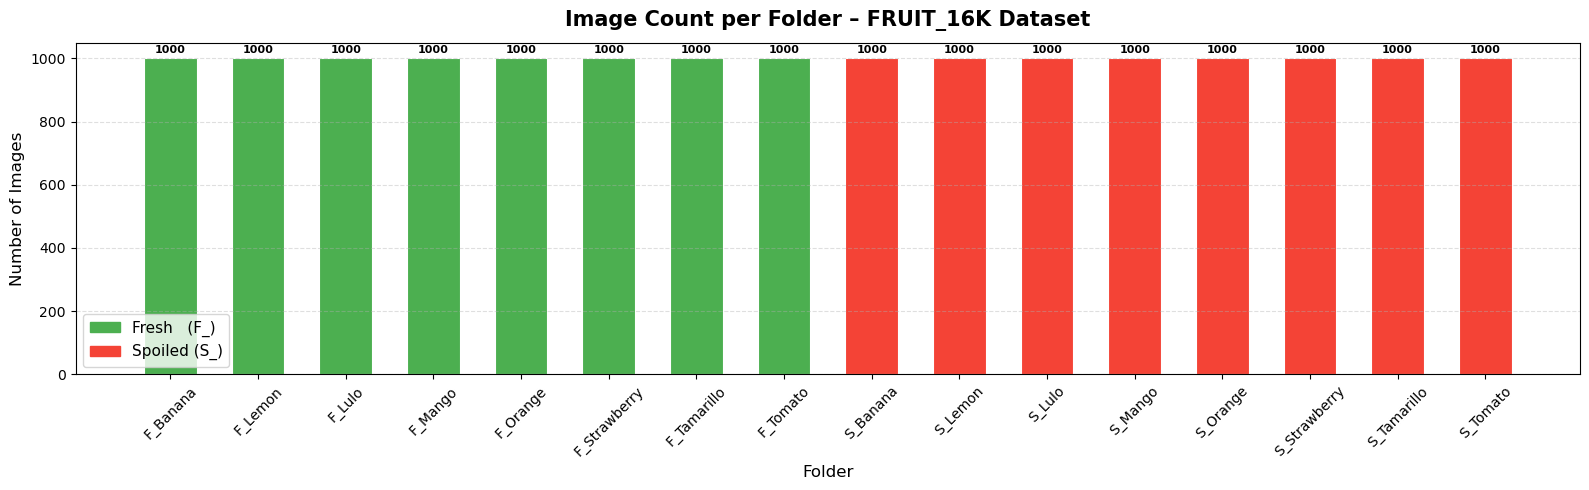

📊 Plot 1 saved → plot1_folder_distribution.png


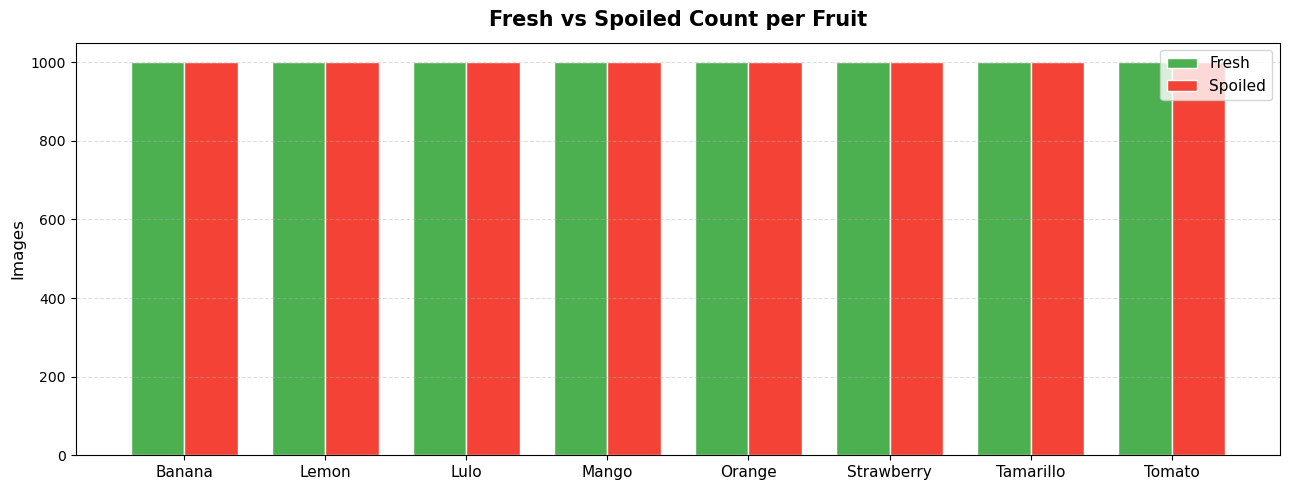

📊 Plot 2 saved → plot2_fresh_vs_spoiled.png


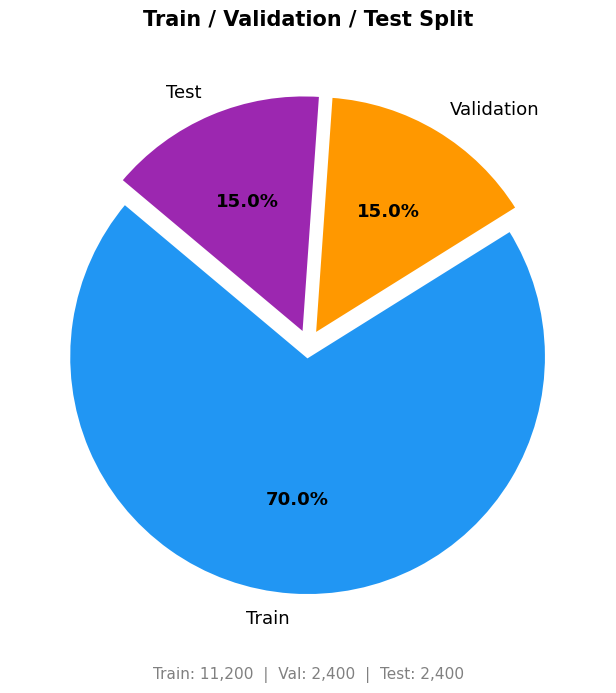

📊 Plot 3 saved → plot3_dataset_split.png


C:\Users\kavin\AppData\Local\Temp\ipykernel_9192\1635176561.py:137: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kavin\AppData\Local\Temp\ipykernel_9192\1635176561.py:138: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("plot4_sample_grid.png", dpi=150, bbox_inches="tight")
C:\Users\kavin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


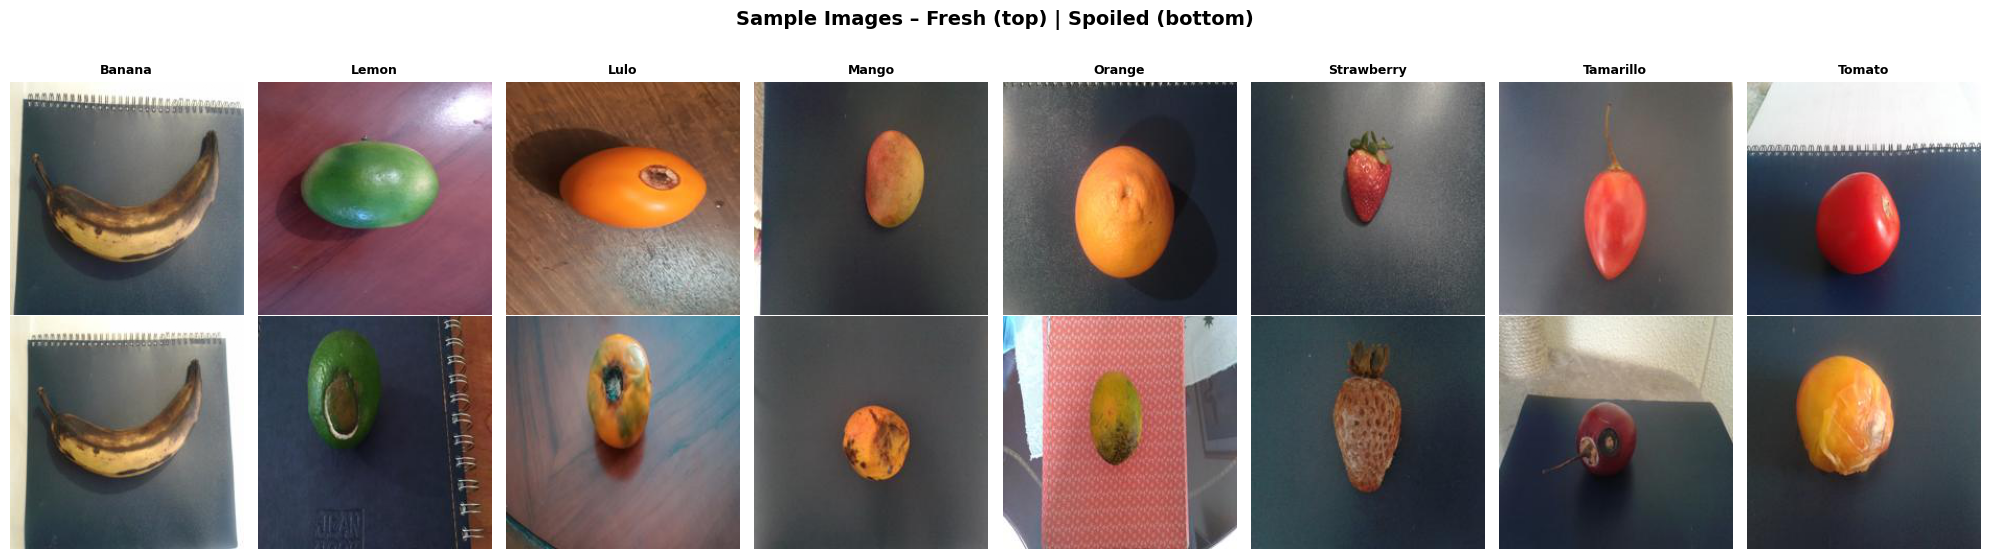

📊 Plot 4 saved → plot4_sample_grid.png


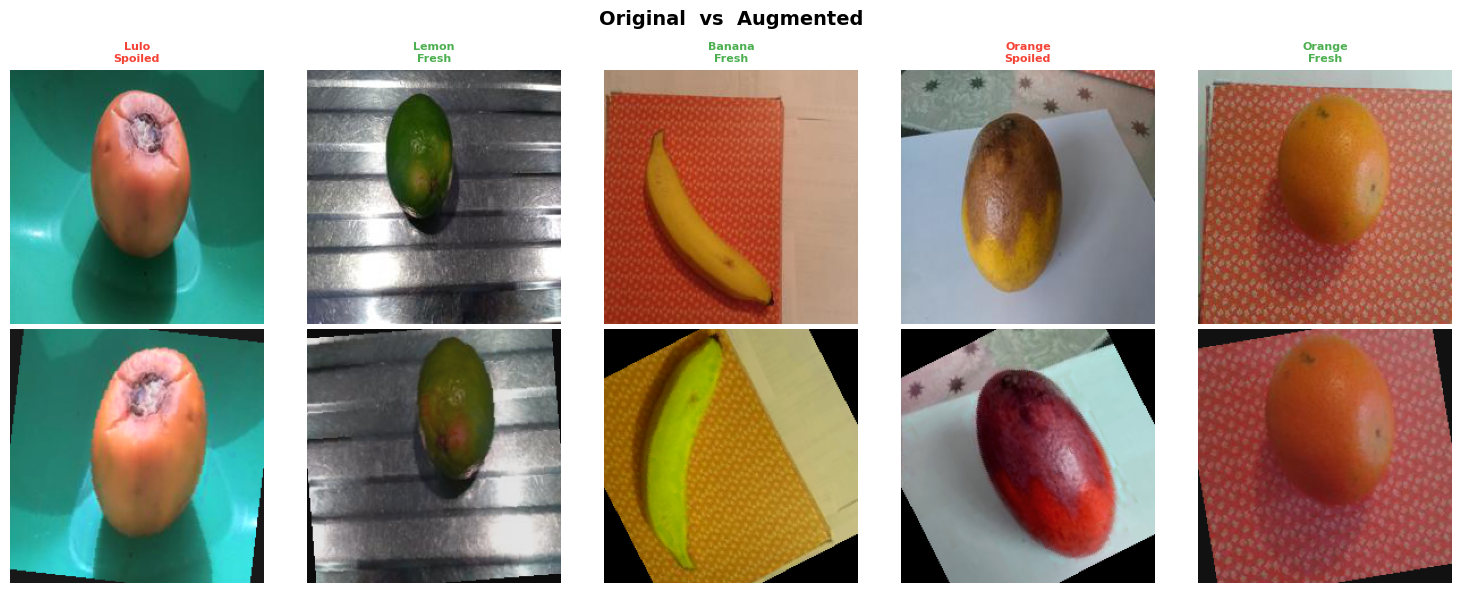

📊 Plot 5 saved → plot5_augmentation_comparison.png


In [7]:
# ─────────────────────────────────────────────
# 6. VISUALISATION
# ─────────────────────────────────────────────
 
def denormalize(tensor):
    """Undo ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)
 
 
# ── PLOT 1: Images per folder (bar chart) ────────────────────
folder_counts  = Counter(all_folders)
sorted_folders = sorted(folder_counts.keys())
counts         = [folder_counts[f] for f in sorted_folders]
bar_colors     = [FRESH_COLOR if f.startswith("F_") else SPOILED_COLOR
                  for f in sorted_folders]
 
fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(sorted_folders, counts, color=bar_colors,
              edgecolor="white", linewidth=0.8, width=0.6)
ax.set_title("Image Count per Folder – FRUIT_16K Dataset",
             fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Folder", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.tick_params(axis="x", rotation=45)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            str(cnt), ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color=FRESH_COLOR,   label="Fresh   (F_)"),
    mpatches.Patch(color=SPOILED_COLOR, label="Spoiled (S_)"),
], fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("plot1_folder_distribution.png", dpi=150)
plt.show()
print("📊 Plot 1 saved → plot1_folder_distribution.png")
 
 
# ── PLOT 2: Fresh vs Spoiled per Fruit (grouped bar) ─────────
fresh_cnt   = defaultdict(int)
spoiled_cnt = defaultdict(int)
for folder, count in folder_counts.items():
    prefix, fruit = folder.split("_", 1)
    if prefix == "F":
        fresh_cnt[fruit]   += count
    else:
        spoiled_cnt[fruit] += count
 
fruits_sorted = sorted(set(fresh_cnt) | set(spoiled_cnt))
x = np.arange(len(fruits_sorted))
w = 0.38
 
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, [fresh_cnt[f]   for f in fruits_sorted],
       w, label="Fresh",   color=FRESH_COLOR,   edgecolor="white")
ax.bar(x + w/2, [spoiled_cnt[f] for f in fruits_sorted],
       w, label="Spoiled", color=SPOILED_COLOR, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(fruits_sorted, fontsize=11)
ax.set_ylabel("Images", fontsize=12)
ax.set_title("Fresh vs Spoiled Count per Fruit",
             fontsize=15, fontweight="bold", pad=12)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("plot2_fresh_vs_spoiled.png", dpi=150)
plt.show()
print("📊 Plot 2 saved → plot2_fresh_vs_spoiled.png")
 
 
# ── PLOT 3: Train / Val / Test split (pie) ───────────────────
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [len(train_idx), len(val_idx), len(test_idx)],
    labels=["Train", "Validation", "Test"],
    autopct="%1.1f%%",
    colors=["#2196F3", "#FF9800", "#9C27B0"],
    explode=(0.05, 0.05, 0.05),
    textprops={"fontsize": 13},
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontweight("bold")
ax.set_title("Train / Validation / Test Split",
             fontsize=15, fontweight="bold", pad=15)
ax.text(0, -1.4,
        f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}  |  Test: {len(test_idx):,}",
        ha="center", fontsize=11, color="grey")
plt.tight_layout()
plt.savefig("plot3_dataset_split.png", dpi=150)
plt.show()
print("📊 Plot 3 saved → plot3_dataset_split.png")
 
 
# ── PLOT 4: Sample image grid (Fresh / Spoiled × 8 fruits) ───
# Collect one image per folder
sample_images = {}   # folder_name → (tensor, fruit, label)
for img_path, label, fruit, folder in base_dataset.samples:
    if folder not in sample_images:
        img = Image.open(img_path).convert("RGB")
        sample_images[folder] = (raw_transforms(img), fruit, label)
    if len(sample_images) == 16:
        break
 
fig, axes = plt.subplots(2, len(FRUIT_NAMES),
                          figsize=(len(FRUIT_NAMES) * 2.5, 5.5))
fig.suptitle("Sample Images – Fresh (top) | Spoiled (bottom)",
             fontsize=14, fontweight="bold", y=1.02)
 
for col, fruit in enumerate(FRUIT_NAMES):
    for row, prefix in enumerate(["F", "S"]):
        folder = f"{prefix}_{fruit}"
        ax     = axes[row][col]
        if folder in sample_images:
            tensor, _, label = sample_images[folder]
            ax.imshow(tensor.permute(1, 2, 0).numpy())
            color = FRESH_COLOR if prefix == "F" else SPOILED_COLOR
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color="grey")
        ax.axis("off")
        if row == 0:
            ax.set_title(fruit, fontsize=9, fontweight="bold")
 
axes[0][0].set_ylabel("✅ Fresh",   fontsize=10, color=FRESH_COLOR,
                       rotation=0, labelpad=55, va="center", fontweight="bold")
axes[1][0].set_ylabel("❌ Spoiled", fontsize=10, color=SPOILED_COLOR,
                       rotation=0, labelpad=55, va="center", fontweight="bold")
 
plt.tight_layout()
plt.savefig("plot4_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 4 saved → plot4_sample_grid.png")
 
 
# ── PLOT 5: Original vs Augmented (5 random images) ──────────
rng_indices = random.sample(range(TOTAL_IMAGES), 5)
 
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Original  vs  Augmented", fontsize=14, fontweight="bold")
axes[0][0].set_ylabel("Original",  fontsize=11, rotation=90, labelpad=8)
axes[1][0].set_ylabel("Augmented", fontsize=11, rotation=90, labelpad=8)
 
for col, idx in enumerate(rng_indices):
    img_path, label, fruit, _ = base_dataset.samples[idx]
    pil  = Image.open(img_path).convert("RGB")
    orig = raw_transforms(pil)
    aug  = train_transforms(pil)
 
    title_color = FRESH_COLOR if label == 0 else SPOILED_COLOR
 
    axes[0][col].imshow(orig.permute(1, 2, 0).numpy())
    axes[0][col].set_title(
        f"{fruit}\n{'Fresh' if label == 0 else 'Spoiled'}",
        fontsize=8, color=title_color, fontweight="bold"
    )
    axes[0][col].axis("off")
 
    axes[1][col].imshow(denormalize(aug).permute(1, 2, 0).numpy())
    axes[1][col].axis("off")
 
plt.tight_layout()
plt.savefig("plot5_augmentation_comparison.png", dpi=150)
plt.show()
print("📊 Plot 5 saved → plot5_augmentation_comparison.png")

In [8]:
# ─────────────────────────────────────────────
# 7. SUMMARY
# ─────────────────────────────────────────────
 
print("\n" + "="*57)
print("      FRESHHARVEST – WEEK 1 PREPROCESSING SUMMARY")
print("="*57)
print(f"  Dataset Root      : {DATASET_ROOT}")
print(f"  Total Images      : {TOTAL_IMAGES:,}")
print(f"  ✅ Fresh          : {all_labels.count(0):,}")
print(f"  ❌ Spoiled        : {all_labels.count(1):,}")
print(f"  Fruits Covered    : {', '.join(FRUIT_NAMES)}")
print(f"  Image Size        : {IMAGE_SIZE[0]} × {IMAGE_SIZE[1]} px")
print(f"  Batch Size        : {BATCH_SIZE}")
print("-"*57)
print(f"  Training Set      : {len(train_idx):,} images  ({len(train_idx)/TOTAL_IMAGES*100:.1f}%)")
print(f"  Validation Set    : {len(val_idx):,}  images  ({len(val_idx)/TOTAL_IMAGES*100:.1f}%)")
print(f"  Test Set          : {len(test_idx):,}  images  ({len(test_idx)/TOTAL_IMAGES*100:.1f}%)")
print("-"*57)
print("  Train Augmentations Applied:")
print("    ✔ RandomCrop 224×224       ✔ Horizontal & Vertical Flip")
print("    ✔ RandomRotation ±30°      ✔ ColorJitter (brightness/contrast/sat/hue)")
print("    ✔ RandomGrayscale (5%)     ✔ ImageNet Normalization")
print("="*57)
print("\n✅ Week 1 complete – ready for CNN model building in Week 2!\n")


      FRESHHARVEST – WEEK 1 PREPROCESSING SUMMARY
  Dataset Root      : C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K
  Total Images      : 16,000
  ✅ Fresh          : 8,000
  ❌ Spoiled        : 8,000
  Fruits Covered    : Banana, Lemon, Lulo, Mango, Orange, Strawberry, Tamarillo, Tomato
  Image Size        : 224 × 224 px
  Batch Size        : 32
---------------------------------------------------------
  Training Set      : 11,200 images  (70.0%)
  Validation Set    : 2,400  images  (15.0%)
  Test Set          : 2,400  images  (15.0%)
---------------------------------------------------------
  Train Augmentations Applied:
    ✔ RandomCrop 224×224       ✔ Horizontal & Vertical Flip
    ✔ RandomRotation ±30°      ✔ ColorJitter (brightness/contrast/sat/hue)
    ✔ RandomGrayscale (5%)     ✔ ImageNet Normalization

✅ Week 1 complete – ready for CNN model building in Week 2!



In [3]:
# ─────────────────────────────────────────────
# 8. SAVE SPLITS FOR WEEKS 2–4
# ─────────────────────────────────────────────
 
torch.save({
    "train_idx"    : train_idx,
    "val_idx"      : val_idx,
    "test_idx"     : test_idx,
    "all_labels"   : all_labels,
    "all_fruits"   : all_fruits,
    "all_folders"  : all_folders,
    "binary_names" : BINARY_NAMES,
    "fruit_names"  : FRUIT_NAMES,
    "dataset_root" : DATASET_ROOT,
}, "freshharvest_splits.pt")
 
print("💾 Splits saved → freshharvest_splits.pt  (reuse in Weeks 2–4)")

NameError: name 'train_idx' is not defined